In [2]:
%cd ..

%load_ext autoreload
%autoreload 2

/home/sake/userdata/sake/rq-vae-transformer-latent-score


/home/sake/.local/share/virtualenvs/rq-vae-transformer-latent-score-bN1rpArz/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [58]:
from rqvae.losses.vqgan import LPIPS

lpips = LPIPS().eval()


/home/sake/.local/share/virtualenvs/rq-vae-transformer-latent-score-bN1rpArz/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/sake/.local/share/virtualenvs/rq-vae-transformer-latent-score-bN1rpArz/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


loaded pretrained LPIPS loss from /home/sake/userdata/sake/rq-vae-transformer-latent-score/rqvae/losses/vqgan/.caches/vgg.pth


/home/sake/userdata/sake/rq-vae-transformer-latent-score/rqvae/losses/vqgan/lpips.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(ckpt, 

In [4]:
import cv2
from torchvision import transforms

image_path = "/home/sake/userdata/olimpic_dataset_yolo/grandstaff-lmx/beethoven/piano-sonatas/sonata01-1/original_m-0-5_yolo_resized.jpg"
img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
img = transforms.ToTensor()(img)
img = transforms.Normalize([0.5],[0.5])(img)

In [5]:
img.shape

torch.Size([1, 112, 368])

In [6]:
img.max(), img.min()

(tensor(1.), tensor(-1.))

In [7]:
image_path1 = "/home/sake/userdata/olimpic_dataset_yolo/grandstaff-lmx/beethoven/piano-sonatas/sonata01-1/original_m-0-5_distorted_yolo_resized.jpg"
img1 = cv2.imread(image_path1, cv2.IMREAD_UNCHANGED)
img1 = transforms.ToTensor()(img1)
img1 = transforms.Normalize([0.5],[0.5])(img1)

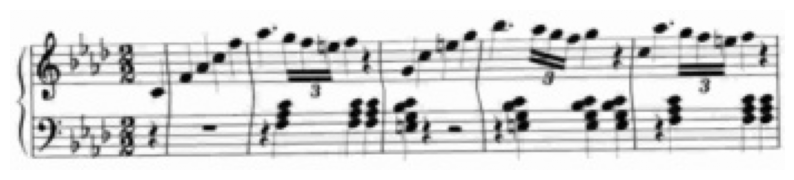

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.imshow(img1.squeeze(), cmap='gray')
plt.axis('off')
plt.show()


In [9]:
img1.shape

torch.Size([1, 72, 348])

In [10]:
img = img[:, :img1.shape[1], :img1.shape[2]]
img.shape

torch.Size([1, 72, 348])

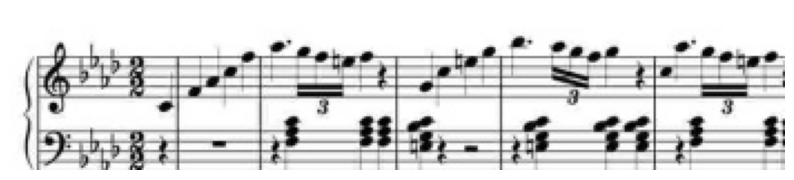

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.imshow(img.squeeze(), cmap='gray')
plt.axis('off')
plt.show()


In [12]:
image_path2= "/home/sake/userdata/olimpic_dataset_yolo/grandstaff-lmx/beethoven/piano-sonatas/sonata01-1/original_m-10-15_distorted_yolo_resized.jpg"
img2 = cv2.imread(image_path2, cv2.IMREAD_UNCHANGED)
img2 = transforms.ToTensor()(img2)
img2 = transforms.Normalize([0.5],[0.5])(img2)
img2.shape


torch.Size([1, 88, 398])

In [13]:
img2 = img2[:, :img1.shape[1], :img1.shape[2]]
img2.shape

torch.Size([1, 72, 348])

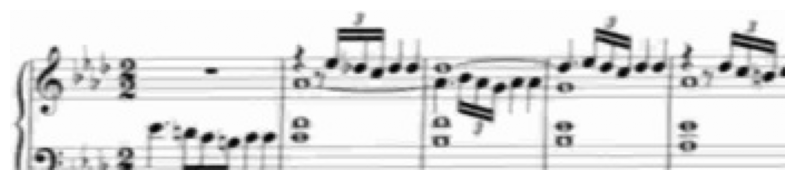

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.imshow(img2.squeeze(), cmap='gray')
plt.axis('off')
plt.show()


In [115]:
import torch
img3 = torch.ones_like(img2)
img3[:, 1:, 1:] = img2[:, :-1, :-1]

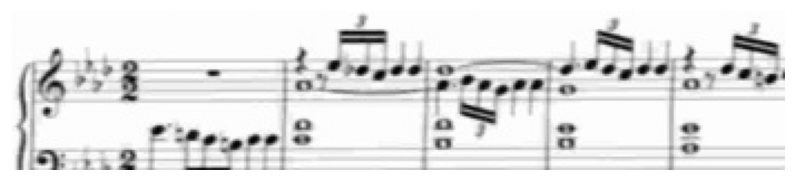

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.imshow(img3.squeeze(), cmap='gray')
plt.axis('off')
plt.show()


In [81]:
lpips(img, img1)

tensor(0.4252)

In [117]:
lpips(img3, img2)

tensor(0.0940)

In [22]:
import torch
from rqvae.losses.vqgan.zeus_lpips import ZeusLPIPS

In [98]:
eyeball = ZeusLPIPS().eval()

/home/sake/userdata/sake/rq-vae-transformer-latent-score/rqvae/losses/vqgan/zeus_lpips.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(pretrained_we

In [121]:
eyeball(img.unsqueeze(0), img1.unsqueeze(0))

tensor(0.3640)

In [120]:
eyeball(img.unsqueeze(0), img2.unsqueeze(0))

tensor(0.4642)

In [119]:
eyeball(img2.unsqueeze(0), img1.unsqueeze(0))

tensor(0.5408)

In [118]:
eyeball(img3.unsqueeze(0), img2.unsqueeze(0))

tensor(0.0490)

In [ ]:
from torchvision import models
vgg_pretrained_features = models.vgg16(pretrained=True).features

/home/sake/.local/share/virtualenvs/rq-vae-transformer-latent-score-bN1rpArz/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/sake/.local/share/virtualenvs/rq-vae-transformer-latent-score-bN1rpArz/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [3]:
vgg_pretrained_features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si